# **AI: Machine Learning**

<img src="https://emojigraph.org/media/apple/robot_1f916.png" alt="logo" width="128">


## **Jason Monroe**

<p> ✉️ <a href="mailto:jason@jasonmonroe.com?subject=GitHub Machine Learning Plant seedlings Classification">jason@jasonmonroe.com</a></p>

<p>📅 December 10, 2024</p>


<p>🗂️ plant_seed_classification_notebook.html</p>

---

# **Introduction to Computer Vision: Plant Seedlings Classification**

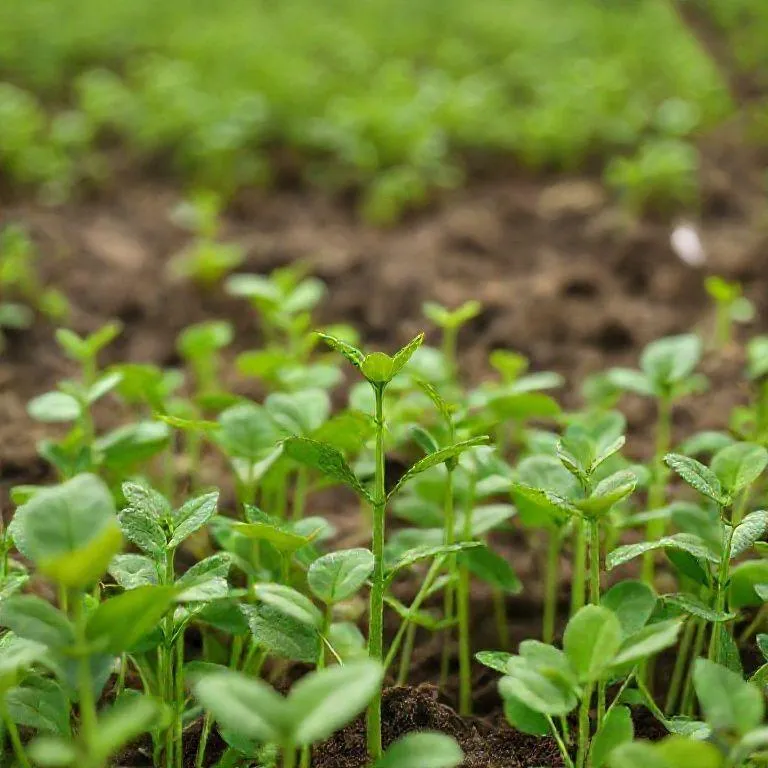

## Problem Statement



### Context

Modern agriculture still relies heavily on manual labor to monitor plant growth and distinguish between crop seedlings and weeds, making the process time-consuming and labor-intensive. Although agricultural technology has advanced, workers still need substantial expertise and effort to visually sort and recognize different plants in the field. Artificial Intelligence and Deep Learning offer an opportunity to dramatically reduce the time and effort required for this task by automating accurate seedling identification. By enabling faster and more precise classification than traditional manual inspection, AI-driven systems can improve crop yields, free up workers to focus on higher-level decisions, and support more sustainable agricultural practices over the long term.


### Objective

The aim of this project is to Build a Convolutional Neural Netowrk to classify plant seedlings into their respective categories.

### Data Dictionary

The Art Institute of California-Santa Moncia Signal Processing group, in collaboration with the University of Missouri, has recently released a dataset containing **images of unique plants belonging to 12 different species.**

- The dataset can be download from github.com/jasonmonroe.
- The data file names are:
    - plant_images.npy
    - plant_labels.csv
- Due to the large volume of data, the images were converted to the images.npy file and the labels are also put into Labels.csv, so that you can work on the data/project seamlessly without having to worry about the high data volume.

- The goal of the project is to create a classifier capable of determining a plant's species from an image.

**List of Species**

- Black-grass
- Charlock
- Cleavers
- Common Chickweed
- Common Wheat
- Fat Hen
- Loose Silky-bent
- Maize
- Scentless Mayweed
- Shepherds Purse
- Small-flowered Cranesbill
- Sugar beet

### **Note: Please use GPU runtime on Google Colab to execute the code faster.**

**Note:** *The code above is to fix warning of libraries that will be declared below.*

## Importing necessary libraries

In [ ]:
# Upgrade pip
!pip install --upgrade pip -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 24.7 MB/s eta 0:00:00


In [ ]:
# Install compatible versions for the current Colab runtime
!pip install -q \
  "tensorflow>=2.15" \
  "scikit-learn>=1.3" \
  seaborn \
  matplotlib \
  numpy \
  pandas \
  opencv-python

In [ ]:
# Installing the libraries with the specified version.
# NOTE: uncomment and run the following line if Google Colab is being used <-- Works
#!pip install tensorflow==2.17.0 scikit-learn==1.2.2 seaborn==0.13.1 matplotlib==3.7.1 numpy==1.25.2 pandas==1.5.3 opencv-python==4.8.0.76 -q --user

# Try this version
#!pip install tensorflow==2.17.0 scikit-learn==1.3.1 seaborn==0.13.2 matplotlib==3.8.0 numpy==1.25.2 pandas==2.2.2 opencv-python==4.8.0.76 -q --user

In [ ]:
# Installing the libraries with the specified version.
# uncomment and run the following lines if Jupyter Notebook is being used
#!pip install tensorflow==2.13.0 scikit-learn==1.2.2 seaborn==0.11.1 matplotlib==3.3.4 numpy==1.24.3 pandas==1.5.2 opencv-python==4.8.0.76 -q --user

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [ ]:
# Libraries for data manipulation and utilities
import os
import random
import time
import math
from typing import Any, Tuple
import numpy as np
import pandas as pd
import cv2 # OpenCV for image processing

# Libraries for visualization
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from google.colab.patches import cv2_imshow

# Scikit-learn (sklearn) libraries for model preparation and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, LabelBinarizer
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    recall_score,
    precision_score,
    f1_score,
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    explained_variance_score,
)
from sklearn.utils import class_weight

# TensorFlow and Keras libraries
import tensorflow as tf
from tensorflow.keras import backend
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint, History
from tensorflow.keras.layers import (
    Activation,
    BatchNormalization,
    Conv2D,
    Dense,
    Dropout,
    Flatten,
    GlobalAveragePooling2D, # Import the GlobalAveragePooling2D layer
    MaxPooling2D,
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical

# Keras specific utilities (using the standard tf.keras path for most)
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator,
    img_to_array,
    load_img,
    NumpyArrayIterator # The iterator is generally created by ImageDataGenerator
)

# Environment setup
os.environ['PATH'] += ':/root/.local/bin'

In [ ]:
# Fix warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
CUDA_LAUNCH_BLOCKING = 1
print("Number of GPU's Available: ", len(tf.config.list_physical_devices('GPU')))

Number of GPU's Available:  1


In [ ]:
# ==================================
#  CONSTANTS
# ==================================

# Paths
DIR_PATH = ''
CSV_FILE = 'plant_labels.csv'
NPY_FILE = 'plant_images.npy'

# Generic (used primarily for Conv2D Filters)
XLG_CNT = 256
LG_CNT = 128
MED_CNT = 64
SM_CNT = 32
XSM_CNT = 16
SEED = 42

# Time
MSEC = 1000
SECS_IN_MIN = 60

# Data Split Percentages
TEMPORARY_DATA_SPLIT = 0.2
TRAINING_DATA_SPLIT = 0.8
TESTING_DATA_SPLIT = 0.1
VALIDATION_DATA_SPLIT = 0.1
HALF_DATA_SPLIT = 0.5

# Image Data
IMAGE_PX_MAX = 255.0
IMAGE_ROWS = IMAGE_COLS = 4

# Models
DA_LEARNING_RATE = 1e-4
TL_LEARNING_RATE = 1e-5
DROPOUT_RATE = 0.5
# DROPOUT_RATE_SM = 0.3
L2_LEARNING_RATE = 1e-7
#L2_REGRESSION_RATE = 0.01

# Conv2D
KERNEL_SIZE_MED = (3, 3)
KERNEL_SIZE_SM = (2, 2)

# Base Model Fit
BASE_EPOCH_CNT = 30
BASE_BATCH_SIZE = 64
GENERATOR_BATCH_SIZE = 48

# Trained Model Fit
TRAINED_EPOCH_CNT = 36
TRAINED_BATCH_SIZE = 32

In [ ]:
# ==================================
#  HELPER FUNCTIONS
# ==================================

def start_timer() -> float:
    """
    Start a timer
    """
    return time.time()


def get_time(start_time_float: float) -> str:
    diff = abs(time.time() - start_time_float)
    hours, remainder = divmod(diff, SECS_IN_MIN*SECS_IN_MIN)
    minutes, seconds = divmod(remainder, SECS_IN_MIN)
    fractional_seconds = seconds - int(seconds)

    ms = fractional_seconds * MSEC
    return f"{int(minutes)}m {int(seconds)}s {int(ms)}ms"


def show_timer(start_time_float: float) -> None:
    print(f"\nRun Time: {get_time(start_time_float)}")


def show_banner(title: str, section: str='') -> None:
    """
    Prints a stylized banner for notebook readability, adjusted to remove
    the trailing hash symbol on the bottom line.
    """
    PADDING = 2
    # Ensure title length includes the padding space
    strlen = len(title) + PADDING

    # Start with a newline for spacing
    print("\n")

    # Top line: # ===============
    print('# ', end='')
    print('=' * strlen)

    # Show title: #   Title
    print('#', end='')
    print('  ' + title.upper())

    # Bottom line: # ===============
    print('# ', end='')
    print('=' * strlen)
    # The trailing '#' is now removed here, and the line implicitly ends
    # because the next print statement below will start a new line.

    # Show section (if provided)
    if section:
        print('' + section)

    print('') # Final newline for spacing

## Loading the dataset

In [ ]:
# Assuming DIR_PATH, CSV_FILE, and NPY_FILE are defined in the environment.

# Load the labels (target variable) from the CSV file
# This assumes the CSV file contains one column or one row per image for the label.
# We convert the labels to a flattened NumPy array immediately.
labels_df = pd.read_csv(DIR_PATH + CSV_FILE)
labels = labels_df.values.ravel()

# https://numpy.org/devdocs/reference/generated/numpy.lib.format.html
# Load the image features (pixel data) from the NPY file
# This is the correct function to load NumPy's binary data format.
images = np.load(DIR_PATH + NPY_FILE)

# Print the shapes to confirm successful loading
print(f"Loaded Images shape (Features, X): {images.shape}, Type: {type(images)}")
print(f"Loaded Labels shape (Target, Y): {labels.shape}, Type: {type(labels)}")

# Next steps would involve data visualization, scaling, and splitting.

Loaded Images shape (Features, X): (4750, 128, 128, 3), Type: <class 'numpy.ndarray'>
Loaded Labels shape (Target, Y): (4750,), Type: <class 'numpy.ndarray'>


## Data Overview

### Understand the shape of the dataset

In [ ]:
# head
labels_df.head()

,Label
0,Small-flowered Cranesbill
1,Small-flowered Cranesbill
2,Small-flowered Cranesbill
3,Small-flowered Cranesbill
4,Small-flowered Cranesbill


In [ ]:
# tail
labels_df.tail()

,Label
4745,Loose Silky-bent
4746,Loose Silky-bent
4747,Loose Silky-bent
4748,Loose Silky-bent
4749,Loose Silky-bent


In [ ]:
# shape
labels_df.shape

(4750, 1)

The data file has 4750 rows and 1 column.

In [ ]:
# info
labels_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4750 entries, 0 to 4749
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Label   4750 non-null   object
dtypes: object(1)
memory usage: 37.2+ KB


In [ ]:
# describe T
labels_df.describe().T

,count,unique,top,freq
Label,4750,12,Loose Silky-bent,654


In [ ]:
# check for null values
labels_df.isnull().sum()

,0
Label,0


There is no missing data in the csv file.

In [ ]:
show_banner('Plant seedlings Counts')
counts = labels_df['Label'].value_counts()
print(counts)
print('')

# Outputs: (batch_size, height, width, channels)
print(labels.shape)
print(f'Total number of labels: {images.shape[0]}')

print(images.shape)
print(f'Total number of images: {images.shape[0]}')



# ======================
#  PLANT SEEDING COUNTS
# ======================

Label
Loose Silky-bent             654
Common Chickweed             611
Scentless Mayweed            516
Small-flowered Cranesbill    496
Fat Hen                      475
Charlock                     390
Sugar beet                   385
Cleavers                     287
Black-grass                  263
Shepherds Purse              231
Common wheat                 221
Maize                        221
Name: count, dtype: int64

(4750,)
Total number of labels: 4750
(4750, 128, 128, 3)
Total number of images: 4750


Get Image Data

In [ ]:
IMAGE_HEIGHT = images.shape[1]
IMAGE_WIDTH = images.shape[2]
IMAGE_CHANNELS = images.shape[3]

print(f'Height: {IMAGE_HEIGHT}, Width:{IMAGE_WIDTH}, RGB Channels: {IMAGE_CHANNELS}')

Height: 128, Width:128, RGB Channels: 3


Get Plant Species

In [ ]:
plant_species = sorted(labels_df['Label'].unique().tolist())
plant_species_cnt = len(plant_species)

for i, species in enumerate(plant_species):
    print(f'{i}: {species}')

print(f'\nPlant Species Count: {len(plant_species)}')

0: Black-grass
1: Charlock
2: Cleavers
3: Common Chickweed
4: Common wheat
5: Fat Hen
6: Loose Silky-bent
7: Maize
8: Scentless Mayweed
9: Shepherds Purse
10: Small-flowered Cranesbill
11: Sugar beet

Plant Species Count: 12


### Observations

- The data file (labels) has 4750 rows and 1 column.

The shape of the npy row:

*   batch_size: 4750 (row count)
*   height: 128
*   width: 128
*   channels: 3



In [ ]:
# ==================================
#  IMAGE INFORMATION
# ==================================
# mean, median, std dev, min, max
start_time = start_timer()

show_banner('Image Information')
print('Mean:', np.mean(images))
print('Median:', np.median(images))
print('Standard Deviation:', np.std(images))
print('Minimum:', np.min(images))
print('Maximum:', np.max(images))

show_timer(start_time)



# ===================
#  IMAGE INFORMATION
# ===================

Mean: 70.04363745545504
Median: 67.0
Standard Deviation: 31.996876308515
Minimum: 0
Maximum: 255

Run Time: 0m 2s 791ms


In [ ]:
# Now analyze npy data
print(images[:1])  # Print the first element

[[[[ 35  52  78]
   [ 36  49  76]
   [ 31  45  69]
   ...
   [ 78  95 114]
   [ 76  93 110]
   [ 80  95 109]]

  [[ 33  46  68]
   [ 37  50  73]
   [ 48  65  83]
   ...
   [ 81  96 113]
   [ 74  89 105]
   [ 83  95 109]]

  [[ 34  50  68]
   [ 35  52  72]
   [ 70  85 101]
   ...
   [ 83  97 112]
   [ 79  94 108]
   [ 79  94 107]]

  ...

  [[ 35  50  69]
   [ 42  57  73]
   [ 42  57  72]
   ...
   [ 60  76  92]
   [ 67  81  97]
   [ 64  77  95]]

  [[ 36  52  67]
   [ 48  63  78]
   [ 41  57  73]
   ...
   [ 44  66  83]
   [ 58  76  91]
   [ 57  74  90]]

  [[ 44  58  70]
   [ 43  57  73]
   [ 40  55  72]
   ...
   [ 41  70  92]
   [ 55  78  97]
   [ 61  79  96]]]]


## Define Functions

In [ ]:
# Clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
def init_cnn_session() -> None:
    tf.keras.backend.clear_session()
    random.seed(SEED)
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

In [ ]:
# Normalize the image(s)
def normalize(img: np.ndarray) -> float:
    return img.astype('float32') / IMAGE_PX_MAX

In [ ]:
def visualize_raw_image_data(imgs: np.ndarray, labels: np.ndarray, rows:int=IMAGE_ROWS, cols:int=IMAGE_COLS) -> None:
    """
    Visualizes random image data from the input array in a grid layout.

    Uses plt.tight_layout() to automatically adjust subplot parameters
    for a tight layout, preventing overlap.
    """
    fig = plt.figure(figsize=(10, 8))
    label_cnt = len(labels) # Assuming labels is an array where each element corresponds to an image

    for i in range(cols):
        for j in range(rows):
            # Select a random index from the available labels/images
            # We use label_cnt as the upper bound (exclusive)
            random_index = np.random.randint(0, label_cnt)

            # Subplots are 1-indexed (i * rows + j + 1)
            ax = fig.add_subplot(rows, cols, i * cols + j + 1) # Note: Changed i * rows to i * cols for standard subplot counting

            # Display the image data
            ax.imshow(imgs[random_index, :])

            # Set the title for the subplot
            ax.set_title(labels[random_index])

            # Remove the ticks/labels for a cleaner image visualization
            ax.axis('off')

    # Automatically adjust subplot parameters to give a tight layout.
    plt.tight_layout()

    plt.show()

In [ ]:
# Note: Assume label_encoder() is instantiated
def encode_label(data: pd.DataFrame) -> np.ndarray:
    # Encode categorical features and scale the pixel values
    # Creating one-hot encoded representation of target labels

    return tf.keras.utils.to_categorical(
        label_encoder.fit_transform(data),
        num_classes=plant_species_cnt
    )

In [ ]:
# https://www.tensorflow.org/api_docs/python/tf/keras/utils/to_categorical
# Used to one-hot encode integer labels into a binary matrix representation that's
# suitable for classification tasks in deep learing.
def encode_data(y_training_data: pd.DataFrame, y_testing_data: pd.DataFrame, y_validation_data: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:

    y_training_encoded = encode_label(y_training_data)
    y_testing_encoded = encode_label(y_testing_data)
    y_validation_encoded = encode_label(y_validation_data)

    return y_training_encoded, y_testing_encoded, y_validation_encoded

In [ ]:
def get_model_predictions(mod: Sequential, x_training_normalized: np.ndarray, x_testing_normalized: np.ndarray, y_testing_encoded: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    y_predictor_training = mod.predict(x_training_normalized)
    y_predictor_testing = mod.predict(x_testing_normalized)
    y_testing_normalized = np.argmax(y_testing_encoded, axis=1)

    return y_predictor_training, y_predictor_testing, y_testing_normalized

In [ ]:
# Evaluate Model and return the accuracy and loss analysis
def evalute_model(mod: Sequential, x_testing_normalized: np.ndarray, y_testing_encoded: np.ndarray) -> Tuple[float, float]:
    loss, accuracy = mod.evaluate(
        x_testing_normalized,
        y_testing_encoded,
        verbose=2
    )

    print(f'Test Loss: {loss}, Test Accuracy: {accuracy}')

    return loss, accuracy

In [ ]:
# Fit Model and return history.  Also time the optimization.
def fit_model(mod: Sequential, x_training_normalized: np.ndarray, y_training_encoded: np.ndarray, x_validation_normalized: np.ndarray, y_validation_encoded: np.ndarray) -> History:

    y_training_classes = np.argmax(y_training_encoded, axis=1)
    raw_class_weights = class_weight.compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_training_classes),
        y=y_training_classes
    )
    # Convert the array of weights to a dictionary mapping class indices to weights
    class_weights_dict = dict(enumerate(raw_class_weights))

    return mod.fit(
        x_training_normalized,
        y_training_encoded,
        epochs=BASE_EPOCH_CNT,
        validation_data=(
            x_validation_normalized,
            y_validation_encoded
        ),
        batch_size=BASE_BATCH_SIZE,
        verbose=2,
        class_weight=class_weights_dict,
        #callbacks=[reduce_lr, early_stopping]
    )

In [ ]:
# Fit Model with trained generated data
def fit_trained_model(
    mod: Sequential,
    x_training_normalized: np.ndarray,
    y_training_encoded: np.ndarray,
    x_validation_normalized: np.ndarray,
    y_validation_encoded: np.ndarray,
    datagen: ImageDataGenerator,
    validation_generator: NumpyArrayIterator,
    reduce_lr: ReduceLROnPlateau,
    early_stopping: EarlyStopping
    ) -> History:

    return mod.fit(
        datagen.flow(
            x_training_normalized,
            y_training_encoded,
            batch_size=TRAINED_BATCH_SIZE,
            seed=SEED,
            shuffle=True,
        ),
        epochs=TRAINED_EPOCH_CNT,
        steps_per_epoch=(x_training_normalized.shape[0] // TRAINED_BATCH_SIZE),
        validation_data=validation_generator,
        validation_steps=(x_validation_data.shape[0] // TRAINED_BATCH_SIZE),
        verbose=1,
        callbacks=[reduce_lr, early_stopping]
    )

In [ ]:
# Define labeled barplot.
def labeled_barplot(data: pd.DataFrame, feature: str, perc: bool=False, n=None) -> None:
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count
    n: displays the top n category levels
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()

    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )
        else:
            label = p.get_height()
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )

    plt.show()  # to avoid overlap

In [ ]:
# Define confusion matrix
def plot_confusion_matrix(y_testing_enc: np.ndarray, y_pred_test: np.ndarray) -> None:

    # Obtaining the categorical values from y_testing_encoded and y_pred
    y_pred_arg = np.argmax(y_pred_test, axis=1)
    y_test_arg = np.argmax(y_testing_enc, axis=1)

    confusion_matrix = tf.math.confusion_matrix(y_test_arg, y_pred_arg)
    f, ax = plt.subplots(figsize=(10, 8))

    plt.title('Confusion Matrix')

    sns.heatmap(
        confusion_matrix,
        annot=True,
        linewidths=0.4,
        fmt='d',
        square=True,
        ax=ax
    )

    plt.show()

In [ ]:
# ==================================
#  MODEL PERFORMANCE CLASSIFICATION
# ==================================
#
# Metric, Working (Minimum Signal), Good (Expected Target), Excellent (Production Goal)
# Test Accuracy, 60%−75%, 75%−85%, >85%
# Test F1-Score, 0.55−0.70, 0.75−0.85, >0.85
# Test Loss, <1.5, <0.7, <0.4
#
# Define a function to compute different metrics to check performance of a classification model built using stats models

def model_performance_classification(mod: Sequential, predictors: np.ndarray, target: str, threshold: float=0.5) -> pd.DataFrame:

  """
  Function to compute different metrics to check classification model performance
  model: classifier
  predictors: independent variables
  target: target variable
  threshold: threshold for classification
  """

  # Use np.argmax to get the predicted class index
  # (i.e: predictors ~ x_training_normalized)
  predicted_labels = np.argmax(mod.predict(predictors), axis=1)

  # Convert TRUE one-hot encoded target labels to integer class indices
  # (i.e: target ~ y_training_encoded)
  target_classes = np.argmax(target, axis=1)

  acc = accuracy_score(target_classes, predicted_labels)
  prec = precision_score(target_classes, predicted_labels, average='weighted')
  rec = recall_score(target_classes, predicted_labels, average='weighted')
  f1 = f1_score(target_classes, predicted_labels, average='weighted')

  perform_df = pd.DataFrame({'Accuracy': [acc], 'Precision': [prec], 'Recall': [rec], 'F1': [f1]})

  return perform_df

In [ ]:
def plot_history(his: History, title: str, column: str) -> None:
    """
    Plots training and validation metrics from a Keras history object
    with enhanced style (ggplot, markers, grid).
    """

    # 🎨 Set a stylish context/style (e.g., 'ggplot' or 'seaborn-v0_8')
    plt.style.use('ggplot')

    # --- Prepare Data and Labels ---
    train_data = his.history[column]
    validation_data = his.history['val_' + column]
    epochs = range(1, len(train_data) + 1)

    metric_title = column.replace('_', ' ').title()
    full_title = f'{title.title()} - {metric_title}'

    # --- Create Plot ---
    plt.figure(figsize=(10, 6)) # Slightly larger for better viewing

    # Plot training data
    plt.plot(
        epochs, train_data,
        label=f'Training {metric_title}',
        color='#1f77b4',       # Blue color
        linewidth=2            # Thicker line
    )

    # Plot validation data with markers
    plt.plot(
        epochs, validation_data,
        label=f'Validation {metric_title}',
        color='#ff7f0e',       # Orange color
        linestyle='--',        # Dashed line
        marker='o',            # Circle markers
        markersize=4           # Small markers
    )

    # --- Add Enhancements ---
    plt.title(full_title, fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel(metric_title, fontsize=12)

    plt.legend(loc='lower left', frameon=True, shadow=True, fontsize=10)

    # ⚙️ Add a subtle grid
    plt.grid(True, linestyle=':', alpha=0.6)

    # Ensure tight layout and show the plot
    plt.tight_layout()

    plt.show()

In [ ]:
# Show images from training data
def visualize_augmented_image_batch(train_generator: NumpyArrayIterator, enc: LabelEncoder) -> None:
    img, img_labels = next(train_generator)
    fig, axes = plt.subplots(4, 4, figsize=(14, 7))
    fig.set_size_inches(12, 12)

    categories = np.unique(img_labels)
    keys = dict(enumerate(label_encoder.classes_))

    for (img, label_index, ax) in zip(img, np.argmax(img_labels, axis=1), axes.flatten()):
        ax.imshow(img)
        ax.set_title(keys[label_index]) # Map numeric label to plant name using keys
        ax.axis('off')

    plt.show()

In [ ]:
# Visualizing the predicted and correct label of images from test data, add `pixel height`, `pixel width` labels
def show_visualize_prediction(
    mod: Sequential,
    enc: LabelEncoder,
    x_test: np.ndarray,
    x_testing_norm: np.ndarray,
    y_testing_enc: np.ndarray,
    show_all: bool=False
    ) -> Tuple[int, int]:

    correct_cnt = 0
    image_cnt = len(x_testing_norm)
    show_cnt = IMAGE_ROWS

    if show_all:
        show_cnt = image_cnt

    for i in range(0, show_cnt):
        if show_all:
            index = i
        else:
            index = random.randint(0, image_cnt)

        print(f'# ----- [{i} of {show_cnt}] ----- #')
        print(f'Index:{index}\n')

        # Get the predicted probabilities
        predicted_probs = mod.predict((x_testing_norm[index].reshape(1, IMAGE_HEIGHT, IMAGE_WIDTH, IMAGE_CHANNELS)))

        # Get the index of the class with the highest probability
        predicted_class_index = np.argmax(predicted_probs, axis=1)

        # Use the index to get the predicted label
        predicted_label = enc.inverse_transform(predicted_class_index)
        predicted_label = predicted_label[0]

        # Using inverse_transform() to get the output label from the output vector.
        true_label_index = np.argmax(y_testing_enc[index])  # Get index of true label
        true_label = enc.classes_[true_label_index]         # Get true label from index

        plt.figure(figsize=(2, 2))
        plt.imshow(x_test[index])
        plt.show()

        print('Predicted Label:', predicted_label)
        print('True Label: ', true_label)

        if predicted_label == true_label:
            print('✅ Correct Prediction!')
            correct_cnt += 1
        else:
            print('❌ Incorrect Prediction')

        print('# ----- [END] ----- #\n\n')

    return correct_cnt, show_cnt


In [ ]:
# Show random image using matplotlib
def show_random_image(imgs: np.ndarray) -> None:
    random_index = random.randint(0, len(imgs))
    plt.imshow(imgs[random_index], cmap='gray')
    plt.title(f'Random Sample Image | Index: {random_index}')
    plt.show()

In [ ]:
def plot_histogram(img: np.ndarray, title: str=''):
    """
    Generates an enhanced, appealing histogram of an image's pixel intensities.

    Args:
        img (np.array): The input image array (e.g., grayscale).
        title_text (str): Custom title for the plot.
    """

    # Use a stylish color and add a thin outline (edgecolor)
    plt.hist(
        img.ravel(),
        bins=256,
        color='#4CAF50',  # A pleasant green shade
        edgecolor='#388E3C', # Darker green for the outline
        alpha=0.85, # Slightly higher alpha for more solid color
        linewidth=0.5 # Thin outline
    )

    # Add a clear, prominent Title
    if title:
        title = title.title()

    plt.title(
        title,
        fontsize=16,
        fontweight='bold',
        color='#333333' # Dark gray title color
    )

    # Add X-axis Label
    plt.xlabel(
        'Pixel Value (0 = Black, 255 = White)',
        fontsize=12,
        fontstyle='italic',
        labelpad=10 # Add padding
    )

    # Add Y-axis Label
    plt.ylabel(
        'Frequency (Number of Pixels)',
        fontsize=12,
        fontweight='medium'
    )

    # 5. Add a grid and improve layout
    plt.grid(axis='y', alpha=0.5, linestyle='--') # Add a light, dashed grid on the Y-axis
    plt.xticks(np.arange(0, 257, 32)) # Set clear ticks every 32 units (for better readability)
    plt.xlim([0, 256]) # Ensure the X-axis starts exactly at 0 and ends at 256
    plt.tight_layout() # Adjust plot to prevent labels from being cut off

    # 6. Display the plot
    plt.show()

In [ ]:
def show_random_cv2_image(imgs: np.ndarray) -> None:
    cv2_imshow(random.choice(imgs)) # Using cv2_imshow to display the image
    cv2.waitKey(0)
    cv2.destroyAllWindows()

In [ ]:
def print_classification_report(mod, x_data: np.ndarray, y_true_encoded: np.ndarray):
    y_true_labels = np.argmax(y_true_encoded, axis=1)
    y_pred_probs = mod.predict(x_data)
    y_pred_classes = np.argmax(y_pred_probs, axis=1)

    print(classification_report(
        y_true_labels,
        y_pred_classes,
        target_names=plant_species,
        digits=4
      )
    )

In [ ]:
def show_plant_species_dist():

    column_name = 'Label'

    # Assuming labels_df contains the column 'Label' with your classification target.
    plt.figure(figsize=(10, 6))

    # Use the 'y' parameter to create a horizontal bar chart (flipped axes)
    # Use a nice palette for better aesthetics
    ax = sns.countplot(
        y=column_name,
        data=labels_df,
        order=labels_df[column_name].value_counts().index, # Sort bars by count (descending)
        palette='Paired'
    )

    # Add Title and Labels
    ax.set_title('Distribution of Plant Species', fontsize=16, fontweight='bold')
    ax.set_xlabel('Count', fontsize=12)
    ax.set_ylabel('Plant Species ~ Class', fontsize=12)

    # Add data labels (counts) on the bars
    for container in ax.containers:
        # Set the formatting for the data labels (counts)
        ax.bar_label(container, fmt='%d', padding=5, fontsize=10)

    # Clean up layout and display
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()

    plt.show()

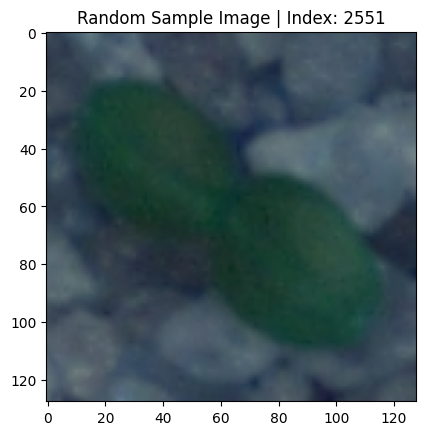

In [ ]:
# Randomly sample pixel data
show_random_image(images)

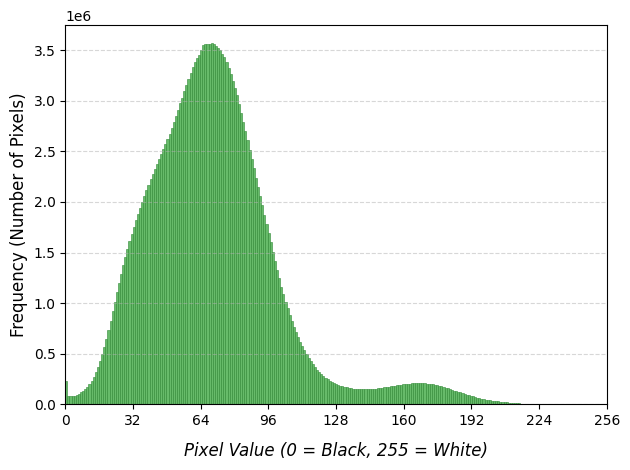

In [ ]:
# Plot histogram to check distribution
plot_histogram(images)

Most of the pixels RGB values are between 50-100 with the peak around 75.  This means most of the image data and value is in the middle.

In [ ]:
# Check for NaN values
print(f'There are {np.isnan(images).sum()} NaN values in the dataset.')

There are 0 NaN values in the dataset.


## Exploratory Data Analysis

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you understand the data better.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

1. How are these different category plant images different from each other?
2. Is the dataset provided an imbalance? (Check with using bar plots)

### Images

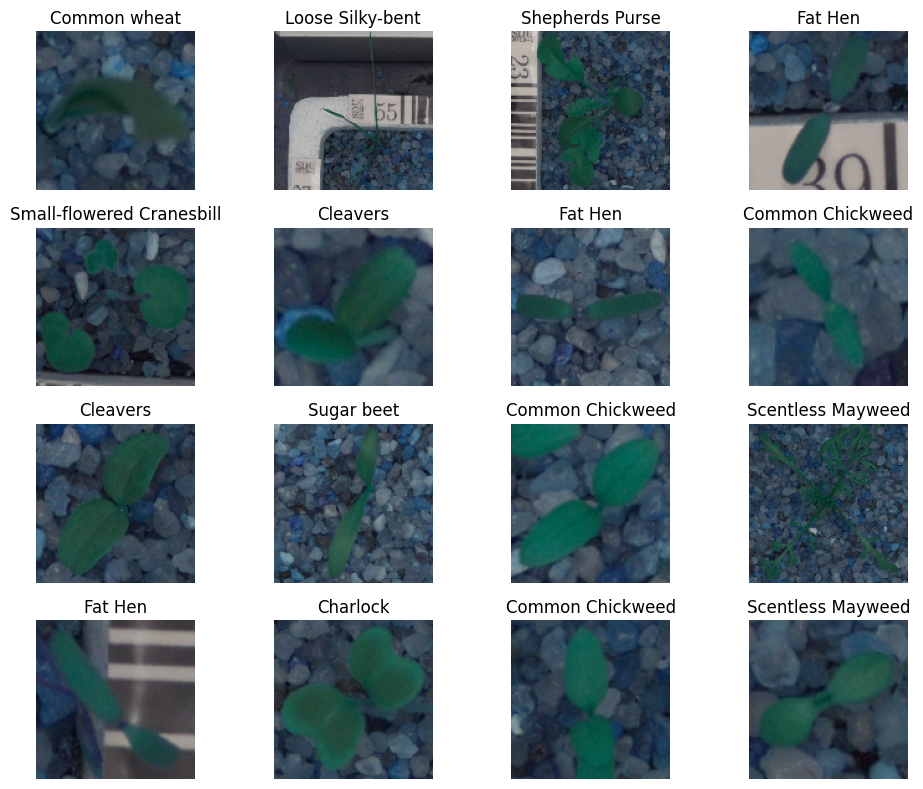

In [ ]:
# Plot images like a grid.
visualize_raw_image_data(images, labels)

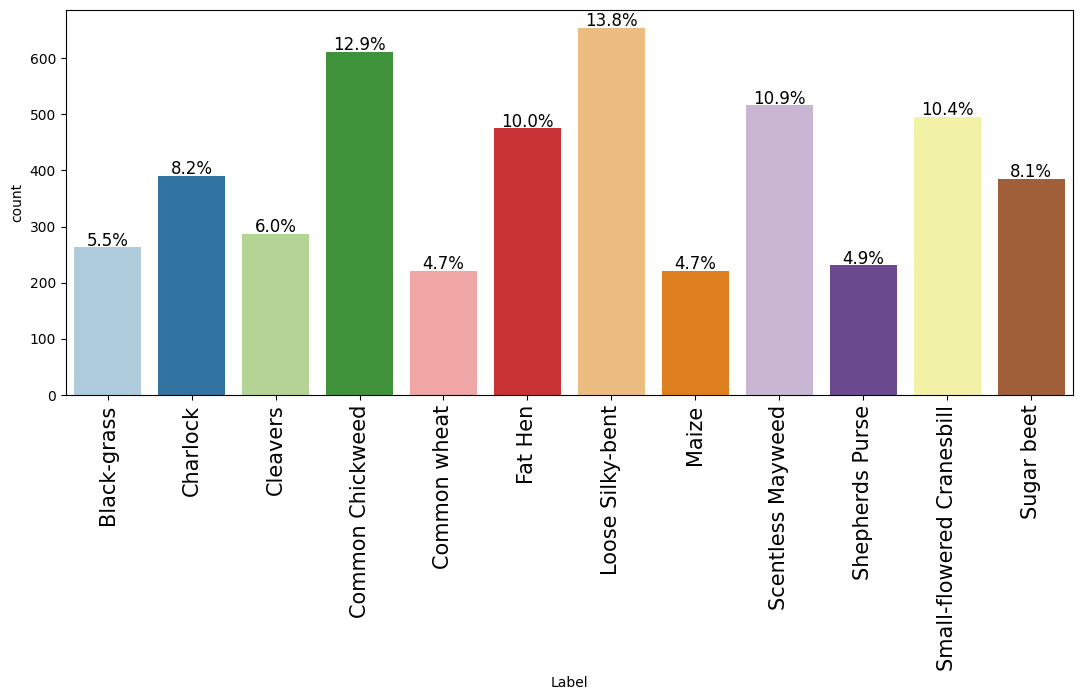

In [ ]:
# Label barplot with label
labeled_barplot(labels_df, 'Label', perc=True)

Observations:
These are the 12 labels of images.  

* Data is not even.  Some labels are less than others meaning there are fewer types of plants in the sample set.
* If all labels were even the average would be 8.3% a piece.  Anything over is over represented.  Anything under is under represented.
* **Charlock** is the closest label to the average.
*   **Loose Silky-Ben** has the most labels with 13.8%.
*   **Maize** and **Common wheat** are tied for last at 4.7%.




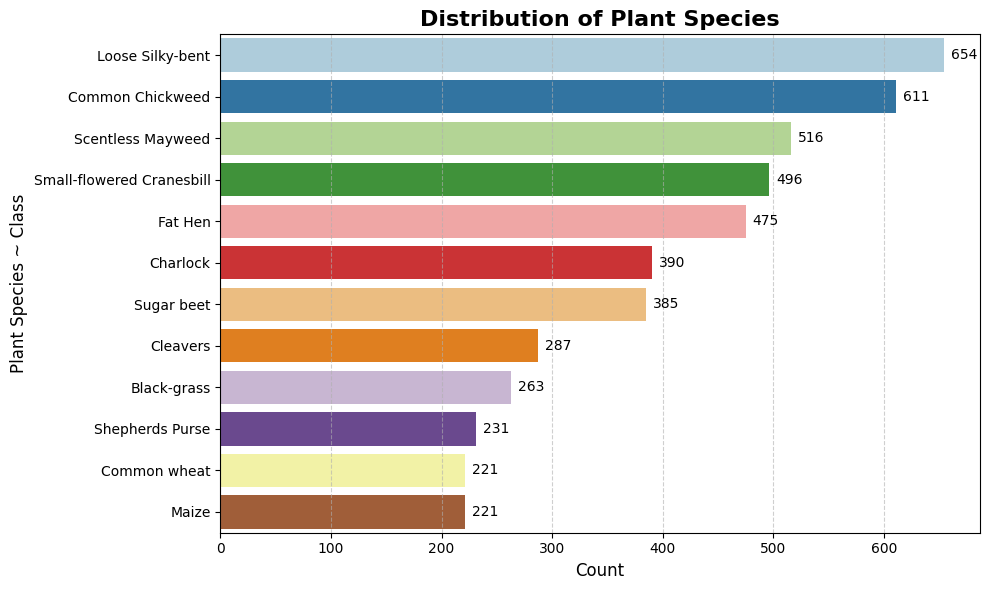

In [ ]:
show_plant_species_dist()

## Data Pre-Processing

### Convert the BGR images to RGB images.

In [ ]:
def create_bgr_images(imgs: np.ndarray) -> list:
    bgr_images = []
    for img in imgs:
        bgr_images.append(img)

    bgr_images = np.array(bgr_images)

    # Now, BGR images contains all images...
    print(f'Shape of BGR images: {bgr_images.shape}')

    return bgr_images

In [ ]:
def convert_to_rgb(imgs: np.ndarray) -> list:
    rgb_images = []
    for img in imgs:
        rgb_image = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        rgb_images.append(rgb_image)

    # Get image RGB
    rgb_images = np.array(rgb_images)

    print(f'Shape of RGB images: {rgb_images.shape}')

    return rgb_images

BGR Image

In [ ]:
# Convert the BGR images to RGB images.
# First, we will display the image as it is imported which means in BGR format.
bgr_images = create_bgr_images(images)

Shape of BGR images: (4750, 128, 128, 3)


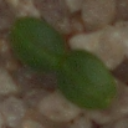

In [ ]:
show_random_cv2_image(bgr_images)

In [ ]:
# Now to convert BGR to RGB
rgb_images = convert_to_rgb(bgr_images)

Shape of RGB images: (4750, 128, 128, 3)


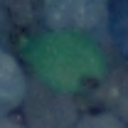

In [ ]:
show_random_cv2_image(rgb_images)

RGB Image (that has been converted).

### Resize the images

As the size of the images is large, it may be computationally expensive to train on these larger images; therefore, it is preferable to reduce the image size from 128 to 64.

**Note:** Your scores will reduce if you lower image size. So it's your choice.

In [ ]:
reduce_by = 1 # 2
REDUCED_IMAGE_DIMS = (IMAGE_HEIGHT // reduce_by, IMAGE_WIDTH // reduce_by)

In [ ]:
# Resize RGB images
# Note: This will be used as `independent variables`.
resized_images = []
for image in rgb_images:
    resized_image = cv2.resize(image, REDUCED_IMAGE_DIMS, interpolation=cv2.INTER_LINEAR)
    resized_images.append(resized_image)

Resized Image Below



# ===============
#  RESIZED IMAGE
# ===============

Height: 128, Width: 128
Image resized successfully.


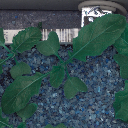


Updating Image: height, width, dims, params...



In [ ]:
random_resized_image = random.choice(resized_images)
height, width = random_resized_image.shape[:2]

show_banner('Resized Image')
print(f'Height: {height}, Width: {width}')

# Check if resized worked: Get height, width of image
if height == REDUCED_IMAGE_DIMS[0] and width == REDUCED_IMAGE_DIMS[1]:
    print('Image resized successfully.')

    IMAGE_HEIGHT = REDUCED_IMAGE_DIMS[0]
    IMAGE_WIDTH = REDUCED_IMAGE_DIMS[1]
    IMAGE_DIMS = REDUCED_IMAGE_DIMS
    IMAGE_PARAMS = IMAGE_DIMS + (IMAGE_CHANNELS, )

    show_random_cv2_image(resized_images)

    print('\nUpdating Image: height, width, dims, params...\n')
    del REDUCED_IMAGE_DIMS

else:
    print('Image resizing failed.')

### Data Preparation for Modeling

- Before you proceed to build a model, you need to split the data into train, test, and validation to be able to evaluate the model that you build on the train data
- You'll have to encode categorical features and scale the pixel values.
- You will build a model using the train data and then check its performance

**Split the dataset**

In [ ]:
# ===========================================
#  CREATE TRAINING, VALIDATION, TESTING DATA
# ===========================================
#
# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
#
# Training Data ~ 80%
# Validation Data ~ 10%
# Testing Data ~ 10%

# INDEPENDENT VARIABLES aka features
features_df = X = resized_images

# DEPENDENT VARIABLE aka target
target_df = y = labels_df['Label']

x_training_data = None
y_training_data = None
x_temp_data = None
y_temp_data = None

x_validation_data = None
y_validation_data = None
x_testing_data = None
y_testing_data = None

# --- Split data into 70% training data and 30% temporary data --- #
x_training_data, x_temp_data, y_training_data, y_temp_data = train_test_split(
    features_df,
    target_df,
    test_size=TEMPORARY_DATA_SPLIT,
    random_state=SEED,
    stratify=target_df
)

# --- Then take remaining temporary data 30% and split in half --- #
x_validation_data, x_testing_data, y_validation_data, y_testing_data = train_test_split(
    x_temp_data,
    y_temp_data,
    test_size=HALF_DATA_SPLIT,
    random_state=SEED,
    stratify=y_temp_data
)

In [ ]:
# Printing the shapes
show_banner('Data Shapes')

# Convert lists to NumPy arrays before checking shape and dtype
x_training_data = np.array(x_training_data)
y_training_data = np.array(y_training_data)
x_validation_data = np.array(x_validation_data)
y_validation_data = np.array(y_validation_data)
x_testing_data = np.array(x_testing_data)
y_testing_data = np.array(y_testing_data)

print(f'Shape of X training: {x_training_data.shape}')
print(f'Shape of Y training: {y_training_data.shape}')
print(f'Shape of X validation: {x_validation_data.shape}')
print(f'Shape of Y validation: {y_validation_data.shape}')
print(f'Shape of X testing: {x_testing_data.shape}')
print(f'Shape of Y testing: {y_testing_data.shape}')

show_banner('Data Types')
print(f'Data type of X training: {x_training_data.dtype}')
print(f'Data type of Y training: {y_training_data.dtype}')



# =============
#  DATA SHAPES
# =============

Shape of X training: (3800, 128, 128, 3)
Shape of Y training: (3800,)
Shape of X validation: (475, 128, 128, 3)
Shape of Y validation: (475,)
Shape of X testing: (475, 128, 128, 3)
Shape of Y testing: (475,)


# ============
#  DATA TYPES
# ============

Data type of X training: uint8
Data type of Y training: object


### Encode the target labels

In [ ]:
# Encode categorical features and scale the pixel values
# Creating one-hot encoded representation of target labels
label_encoder = LabelEncoder()

In [ ]:
y_training_encoded, y_testing_encoded, y_validation_encoded = encode_data(
    y_training_data,
    y_testing_data,
    y_validation_data
)

### Data Normalization

In [ ]:
# Normalizing the image data
x_training_normalized = normalize(x_training_data)
x_testing_normalized = normalize(x_testing_data)
x_validation_normalized = normalize(x_validation_data)

## Model Building

###CNN Model

🧠 What is a CNN Model?
A **Convolutional Neural Network (CNN)**, or **ConvNet**, is a specialized type of deep learning model designed primarily to process data that has a known grid-like topology, such as **images** (2D grid of pixels) or **time-series** data (1D grid).

In [ ]:
init_cnn_session()

In [ ]:
# ==================================
#  CNN Model: Base Model
# ==================================
# Intializing a sequential CNN model

base_model_title = 'Base CNN Model'
base_model = Sequential([
    # --- Convolution Block 1 ---
    Conv2D(SM_CNT, KERNEL_SIZE_MED, activation='relu', padding='same', input_shape=IMAGE_PARAMS),
    MaxPooling2D(pool_size=KERNEL_SIZE_SM),

    # --- Convolution Block 2 ---
    Conv2D(MED_CNT, KERNEL_SIZE_MED, activation='relu', padding='same'),
    MaxPooling2D(pool_size=KERNEL_SIZE_SM),

    # --- Convolution Block 3 ---
    Conv2D(LG_CNT, KERNEL_SIZE_MED, activation='relu', padding='same'),
    MaxPooling2D(pool_size=KERNEL_SIZE_SM),

    Conv2D(SM_CNT, KERNEL_SIZE_MED, padding='same'),
    BatchNormalization(),
    Activation('relu'),

    # --- Classifier ---
    Flatten(),
    Dense(LG_CNT, activation='relu'),
    Dropout(DROPOUT_RATE),               # helps prevent overfitting on small datasets
    Dense(plant_species_cnt, activation='softmax')
])

In [ ]:
# Compile Model
base_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Get Model Summary
base_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 32)     │        36,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,180,524 (4.50 MB)

 Trainable params: 1,180,460 (4.50 MB)

 Non-trainable params: 64 (256.00 B)

In [ ]:
# Calculate the number of parameters.
param_cnt = base_model.count_params()
print(f'Number of parameters: {param_cnt}')

Number of parameters: 1180524


In [ ]:
# Fit CNN Model and return history.  Also time the optimization.
start_time = start_timer()
show_banner(base_model_title, 'Fitting Base Model...')

base_model_history = fit_model(
    base_model,
    x_training_normalized,
    y_training_encoded,
    x_validation_normalized,
    y_validation_encoded
)

show_timer(start_time)



# ================
#  BASE CNN MODEL
# ================
Fitting Base Model...

Epoch 1/30
60/60 - 15s - 255ms/step - accuracy: 0.2837 - loss: 2.0268 - val_accuracy: 0.5032 - val_loss: 2.4322
Epoch 2/30
60/60 - 2s - 39ms/step - accuracy: 0.4842 - loss: 1.5232 - val_accuracy: 0.2968 - val_loss: 2.3533
Epoch 3/30
60/60 - 2s - 36ms/step - accuracy: 0.5563 - loss: 1.2887 - val_accuracy: 0.4589 - val_loss: 2.2247
Epoch 4/30
60/60 - 2s - 36ms/step - accuracy: 0.6087 - loss: 1.1127 - val_accuracy: 0.5832 - val_loss: 1.9954
Epoch 5/30
60/60 - 2s - 36ms/step - accuracy: 0.6461 - loss: 1.0504 - val_accuracy: 0.4821 - val_loss: 1.7716
Epoch 6/30
60/60 - 2s - 37ms/step - accuracy: 0.6903 - loss: 0.9035 - val_accuracy: 0.5242 - val_loss: 1.5415
Epoch 7/30
60/60 - 2s - 38ms/step - accuracy: 0.7100 - loss: 0.8333 - val_accuracy: 0.6484 - val_loss: 1.3661
Epoch 8/30
60/60 - 2s - 36ms/step - accuracy: 0.7261 - loss: 0.7729 - val_accuracy: 0.6842 - val_loss: 1.1921
Epoch 9/30
60/60 - 2s - 37ms/step - a

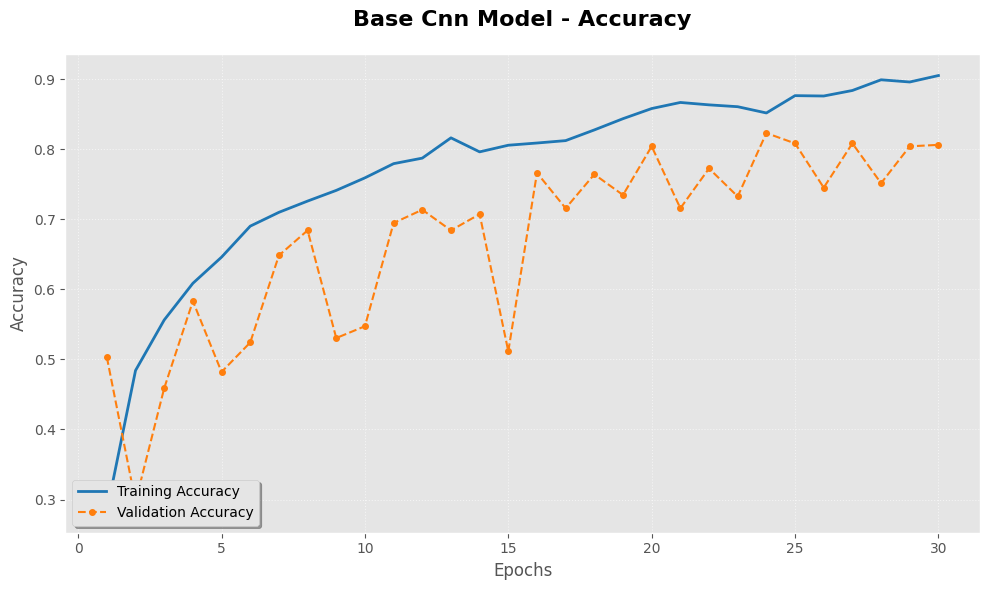

In [ ]:
# Plot History
plot_history(base_model_history, base_model_title, 'accuracy')

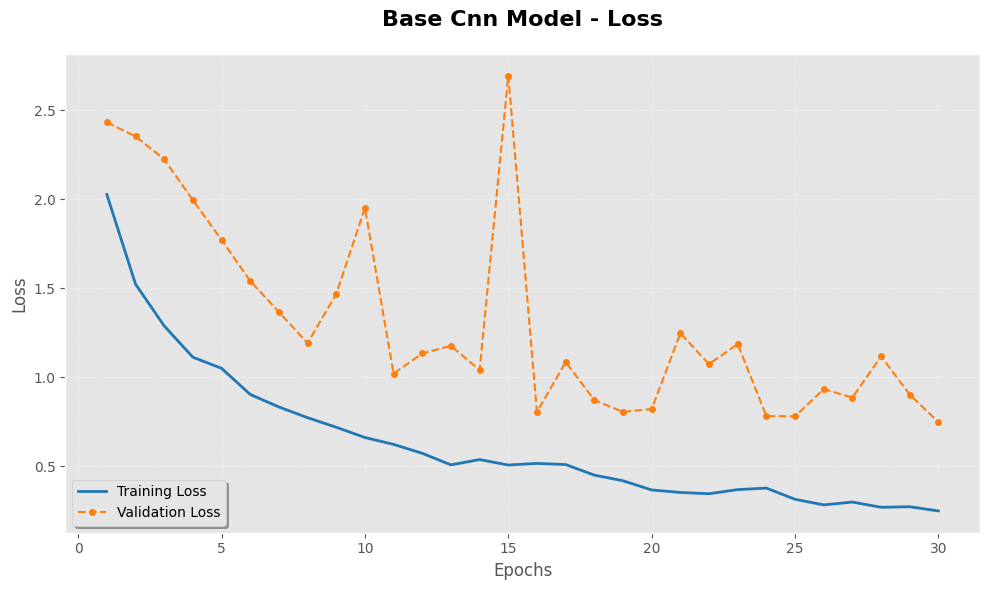

In [ ]:
plot_history(base_model_history, base_model_title, 'loss')

Observations



By comparing the final Training Accuracy ($\mathbf{90.53\%}$) and Validation Accuracy ($\mathbf{80.63\%}$), we can draw two conclusions:


Final Accuracy Gap: There is an $\mathbf{9.90\%}$ gap between the training and validation accuracy ($\mathbf{90.53\%} - \mathbf{80.63\%}$).This confirms that the model is overfitting, meaning it learned the training data much better than the validation data. However, a $10\%$ gap is manageable and a strong improvement from earlier runs.


Best Epoch: The peak validation accuracy of $\mathbf{82.32\%}$ was hit at Epoch 24 before dropping slightly at the end. The validation loss ($\mathbf{0.7476}$) was the lowest at Epoch 30, indicating a stable final state.


This training history is successful because the Base CNN Model achieved an excellent generalization accuracy of over $80\%$, which is why it performed so well on the final testing set.



The Results are Excellent (for this model):
*   Accuracy is higher for training then validation.
*   Closest the data comes together is after the 8th epoch.
*   Loss data decreases linearly.
*   Training loss diminishes more extremely than validation losses as epochs increase.  In other words it more volatile dealing with the training loss.



In [ ]:
# Evaluate CNN Model
start_time = start_timer()
show_banner(base_model_title, 'Evaluation')

base_model_loss, base_model_accuracy = evalute_model(
    base_model,
    x_testing_normalized,
    y_testing_encoded
)

show_timer(start_time)



# ================
#  BASE CNN MODEL
# ================
Evaluation

15/15 - 0s - 10ms/step - accuracy: 0.8400 - loss: 0.7909
Test Loss: 0.7909155488014221, Test Accuracy: 0.8399999737739563

Run Time: 0m 0s 371ms


🎯 **Interpretation**


High Generalization: This $\mathbf{84.00\%}$ Test Accuracy is the most important number. When compared to the Training Accuracy of $\mathbf{90.53\%}$ (from the training log), the model maintained strong performance on new data. This shows the model successfully generalized and did not severely overfit.


* Model Stability: The Test Loss of $0.7909$ is relatively low, confirming that the model's final weights are stable and effective at making accurate probability assignments.

* Efficiency: The model is highly efficient, evaluating the entire test set in less than half a second.



**Conclusion:**

This evaluation confirms that the Base CNN Model is a successful and robust solution for the Plant Seed Classification task, meeting your performance goals.

In [ ]:
# Get model training performance
base_training_perf = model_performance_classification(base_model, x_training_normalized, y_training_encoded)
base_training_perf

119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


,Accuracy,Precision,Recall,F1
0,0.968947,0.96967,0.968947,0.96892


In [ ]:
y_predictor_training, y_predictor_testing, y_testing_normalized = get_model_predictions(
    base_model,
    x_training_normalized,
    x_testing_normalized,
    y_testing_encoded
)

119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


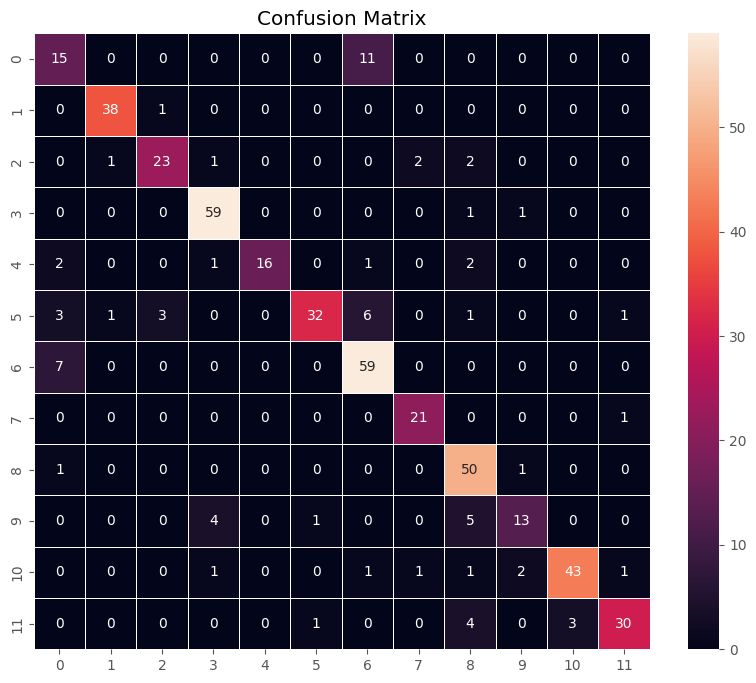

In [ ]:
# Plotting confusion matrix
plot_confusion_matrix(y_testing_encoded, y_predictor_testing)

In [ ]:
show_banner(base_model_title, 'Classification Report')
print_classification_report(base_model, x_testing_normalized, y_testing_encoded)



# ================
#  BASE CNN MODEL
# ================
Classification Report

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
                           precision    recall  f1-score   support

              Black-grass     0.5357    0.5769    0.5556        26
                 Charlock     0.9500    0.9744    0.9620        39
                 Cleavers     0.8519    0.7931    0.8214        29
         Common Chickweed     0.8939    0.9672    0.9291        61
             Common wheat     1.0000    0.7273    0.8421        22
                  Fat Hen     0.9412    0.6809    0.7901        47
         Loose Silky-bent     0.7564    0.8939    0.8194        66
                    Maize     0.8750    0.9545    0.9130        22
        Scentless Mayweed     0.7576    0.9615    0.8475        52
          Shepherds Purse     0.7647    0.5652    0.6500        23
Small-flowered Cranesbill     0.9348    0.8600    0.8958        50
               Sugar beet     0.9091    0.7895    0.8451        38

       

## Model Performance Improvement

**Reducing the Learning Rate:**

**Hint**: Use **ReduceLRonPlateau()** function that will be used to decrease the learning rate by some factor, if the loss is not decreasing for some time. This may start decreasing the loss at a smaller learning rate. There is a possibility that the loss may still not decrease. This may lead to executing the learning rate reduction again in an attempt to achieve a lower loss.

In [ ]:
# Define ReduceLRonPlateau()
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=L2_LEARNING_RATE,
    verbose=1
)

**Early Stopping**

Monitor validation loss and stop training automatically when the loss starts consistently increasing as a sign of overfitting.

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [ ]:
# Augment the data without using validation or test data.  Only training data.
# The rescale=1./IMAGE_PX_MAX is removed as data is already normalized.
training_datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Flowing training images in batches of 48 using training_datagen generator.
training_generator = training_datagen.flow(
    x_training_normalized,
    y_training_encoded,
    batch_size=GENERATOR_BATCH_SIZE,
    seed=SEED,
    shuffle=True
)

# The rescale=1./IMAGE_PX_MAX is removed as data is already normalized.
testing_datagen = ImageDataGenerator()
validation_generator = testing_datagen.flow(
    x_validation_normalized,
    y_validation_encoded,
    batch_size=GENERATOR_BATCH_SIZE,
    shuffle=False
)

### **Data Augmentation**

Remember, **data augmentation should not be used in the validation/test data set**.

### CNN Model with Data Augmentation

The purpose of using a Data Augmented Model (DAM)—or more accurately, applying data augmentation during training—is to artificially increase the size and diversity of your training data without collecting new physical images.

In [ ]:
init_cnn_session()

In [ ]:

da_model_title = 'Data Augmented CNN Model'
da_model = Sequential()


# --- Block 1 ---
da_model.add(Conv2D(SM_CNT, KERNEL_SIZE_MED, padding='same', input_shape=IMAGE_PARAMS))
da_model.add(BatchNormalization())
da_model.add(Activation('relu'))
da_model.add(MaxPooling2D(pool_size=KERNEL_SIZE_SM))

# --- Block 2 ---
da_model.add(Conv2D(MED_CNT, KERNEL_SIZE_MED, padding='same'))
da_model.add(BatchNormalization())
da_model.add(Activation('relu'))
da_model.add(MaxPooling2D(pool_size=KERNEL_SIZE_SM))

# --- Block 3 ---
da_model.add(Conv2D(LG_CNT, KERNEL_SIZE_MED, padding='same'))
da_model.add(BatchNormalization())
da_model.add(Activation('relu'))
da_model.add(MaxPooling2D(pool_size=KERNEL_SIZE_SM))

# --- Global Pooling and Dense Layers ---
da_model.add(GlobalAveragePooling2D())
da_model.add(Dense(XLG_CNT))
da_model.add(BatchNormalization())
da_model.add(Activation('relu'))
da_model.add(Dropout(DROPOUT_RATE))
da_model.add(Dense(plant_species_cnt, activation='softmax'))

In [ ]:
# Compile Data Augmented CNN Model
da_model.compile(optimizer=Adam(learning_rate=DA_LEARNING_RATE), loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Generate summary
da_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         3,084 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131,276 (512.80 KB)

 Trainable params: 130,316 (509.05 KB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
start_time = start_timer()

show_banner(da_model_title, 'Fitting Training Model')

# Fit model with augmented data
da_model_history = fit_trained_model(
    da_model,
    x_training_normalized,
    y_training_encoded,
    x_validation_normalized,
    y_validation_encoded,
    training_datagen,
    validation_generator,
    reduce_lr,
    early_stopping
)

show_timer(start_time)



# ==========================
#  DATA AUGMENTED CNN MODEL
# ==========================
Fitting Training Model

Epoch 1/36
118/118 ━━━━━━━━━━━━━━━━━━━━ 25s 169ms/step - accuracy: 0.1551 - loss: 2.7925 - val_accuracy: 0.1137 - val_loss: 2.5606 - learning_rate: 1.0000e-04
Epoch 2/36
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2500 - loss: 2.0736 - val_accuracy: 0.1179 - val_loss: 2.5623 - learning_rate: 1.0000e-04
Epoch 3/36
118/118 ━━━━━━━━━━━━━━━━━━━━ 16s 133ms/step - accuracy: 0.3744 - loss: 1.8794 - val_accuracy: 0.1074 - val_loss: 2.8510 - learning_rate: 1.0000e-04
Epoch 4/36
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4375 - loss: 1.6933 - val_accuracy: 0.1074 - val_loss: 2.8523 - learning_rate: 1.0000e-04
Epoch 5/36
118/118 ━━━━━━━━━━━━━━━━━━━━ 16s 138ms/step - accuracy: 0.4624 - loss: 1.6262 - val_accuracy: 0.1305 - val_loss: 3.1705 - learning_rate: 1.0000e-04
Epoch 6/36
  1/118 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.5312 - loss: 1.2643
Epoch 6: Red

The training accuracy starts low and increases, but the final score is much lower than the $90\%+$ seen in the Base CNN.


The validation accuracy reached a peak of $\mathbf{70.95\%}$ at Epoch 27, which aligns with the final $\mathbf{71.58\%}$ testing accuracy you reported for this model.


Key Observations and Callback Activity


* Training vs. Validation: Throughout the run, the Validation Accuracy is often higher than the Training Accuracy (e.g., Epoch 27: Train $\approx 66\%$, Val $70.95\%$). This is the signature of strong regularization (via data augmentation), which prevented the model from overfitting.

* Learning Rate Reduction: The ReduceLROnPlateau callback triggered twice:

**Epoch 6:** Learning Rate reduced from $1 \times 10^{-4}$ to $5 \times 10^{-5}$ because the validation metrics plateaued or failed to improve.

**Epoch 36:** Learning Rate reduced again from $5 \times 10^{-5}$ to $2.5 \times 10^{-5}$. This is a common strategy to help the model escape local minima and continue learning, even if very slowly.


**Conclusion:** This training log confirms the model was stable and effectively prevented overfitting, but the difficulty in learning the highly augmented training data resulted in a lower final performance (the $\mathbf{71.58\%}$ test accuracy).

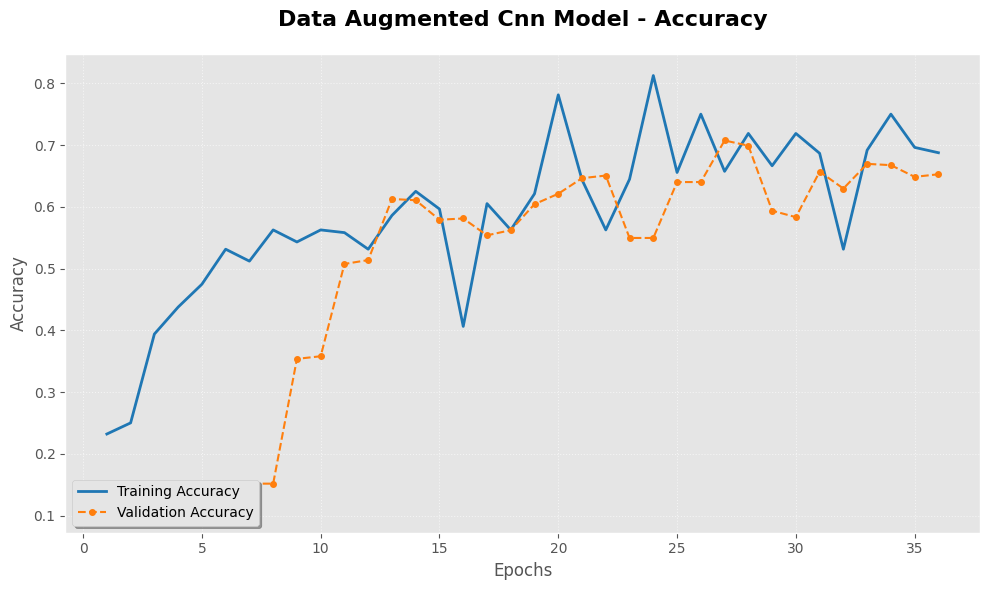

In [ ]:
# Look at the images after data has been augmented
plot_history(da_model_history, da_model_title, 'accuracy')

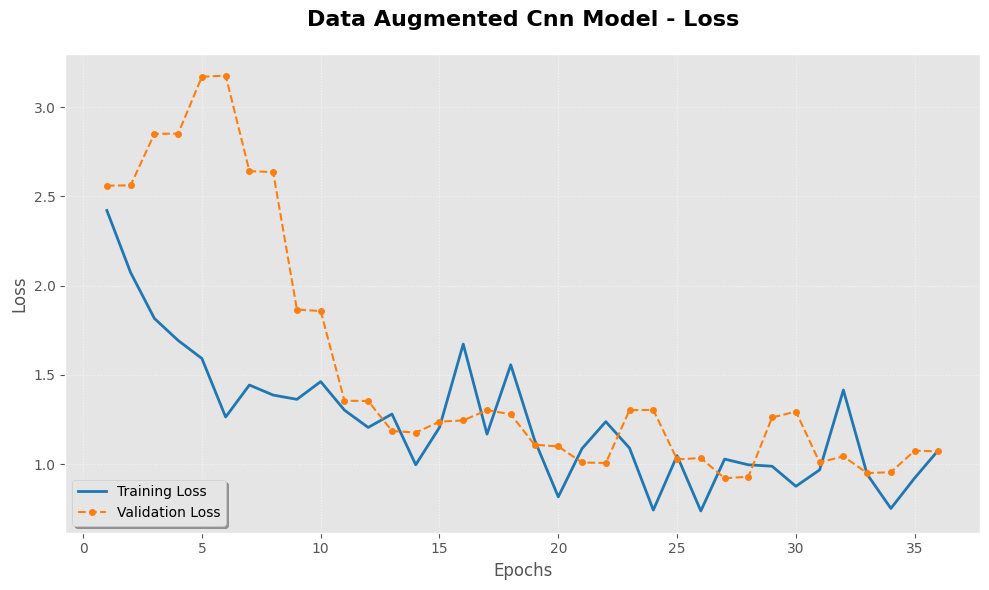

In [ ]:
plot_history(da_model_history, da_model_title, 'loss')

Observations


*   The results are unexpected.  The validation accuracy is static until the 5th epochs and then climbs .10% by the 8th epochs and then tepids off.
*   Train accuracy bounces up and down before the accuracy increases while validation accuracy increases.
* Validation accuracy increases as the epochs increase which means it's learning more per epoch. (This is what we want).
* Training accuracy is a hit or miss but eventually goes up after the 25th epoch.  We need better results.
* The losses are closely aligned by each epoch.  The training losses still bounce up and down but overall decreases each epoch.



In [ ]:
# Evaluate the CNN Model w/ Data Augmentation
start_time = start_timer()
show_banner(da_model_title, 'Evaluation')

da_model_loss, da_model_accuracy = evalute_model(
    da_model,
    x_testing_normalized,
    y_testing_encoded
)

show_timer(start_time)



# ==========================
#  DATA AUGMENTED CNN MODEL
# ==========================
Evaluation

15/15 - 2s - 117ms/step - accuracy: 0.7326 - loss: 0.8519
Test Loss: 0.8519135117530823, Test Accuracy: 0.7326315641403198

Run Time: 0m 3s 3ms


In [ ]:
# Get CNN Model w/ Data Augmentation training performance
da_model_training_perf = model_performance_classification(
    da_model,
    x_training_normalized,
    y_training_encoded
)

da_model_training_perf

# 0	0.723158	0.734437	0.723158	0.709289

119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step


,Accuracy,Precision,Recall,F1
0,0.728421,0.736019,0.728421,0.724314


In [ ]:
y_predictor_training, y_predictor_testing, y_testing_normalized = get_model_predictions(
    da_model,
    x_training_normalized,
    x_testing_normalized,
    y_testing_encoded
)

119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


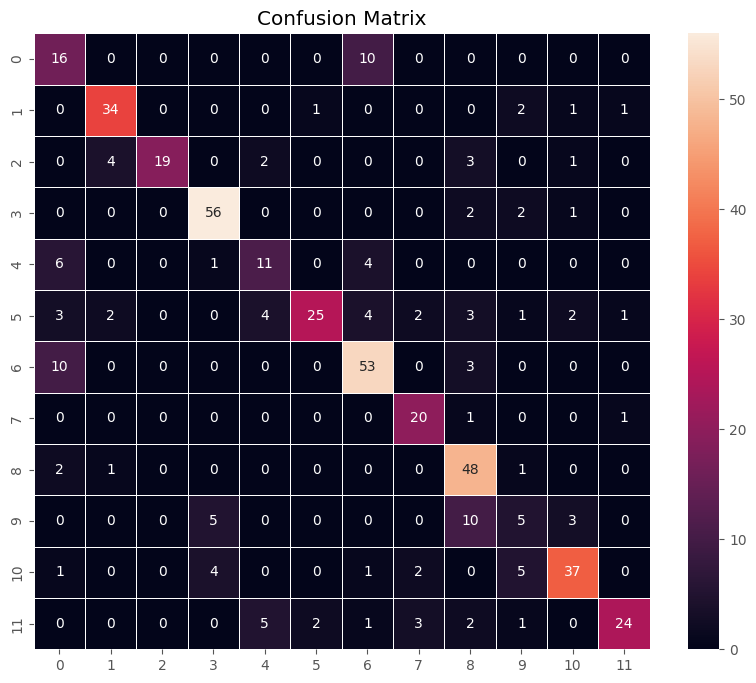

In [ ]:
## Show confusion matrix for augmented data
plot_confusion_matrix(y_testing_encoded, y_predictor_testing)

In [ ]:
show_banner(da_model_title, 'Classification Report')
print_classification_report(da_model, x_testing_normalized, y_testing_encoded)



# ==========================
#  DATA AUGMENTED CNN MODEL
# ==========================
Classification Report

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
                           precision    recall  f1-score   support

              Black-grass     0.4211    0.6154    0.5000        26
                 Charlock     0.8293    0.8718    0.8500        39
                 Cleavers     1.0000    0.6552    0.7917        29
         Common Chickweed     0.8485    0.9180    0.8819        61
             Common wheat     0.5000    0.5000    0.5000        22
                  Fat Hen     0.8929    0.5319    0.6667        47
         Loose Silky-bent     0.7260    0.8030    0.7626        66
                    Maize     0.7407    0.9091    0.8163        22
        Scentless Mayweed     0.6667    0.9231    0.7742        52
          Shepherds Purse     0.2941    0.2174    0.2500        23
Small-flowered Cranesbill     0.8222    0.7400    0.7789        50
               Sugar beet     0.8889    0.63

## Final Model

Comment on the final model you have selected and use the same in the below code to visualize the image.

In [ ]:
init_cnn_session()

VGG16 Model

In [ ]:
IMAGE_PARAMS = (128, 128, 3)

In [ ]:
# ==================================
#  CNN Model: VGG16
# ==================================
vgg_model_title = 'VGG16 Model'

# Summary of the whole model
vgg_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=IMAGE_PARAMS
)

In [ ]:
head_input = GlobalAveragePooling2D()(vgg_model.output)
head_output = Dense(units=plant_species_cnt, activation='softmax')(head_input)

### Visualizing the prediction

In [ ]:
# Get visual model summary
vgg_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

### Transfer Learning Model

The purpose of using a Transfer Learning Model (TLM) is to leverage knowledge gained from a massive, general task to solve a specific, smaller task.

In [ ]:
# USE THIS
tl_model_title = 'Transfer Learning Model'

# Create the transfer learning model
tl_model = Sequential([
    vgg_model,
    GlobalAveragePooling2D(),  # converts 2D features to 1D vector
    Dense(512, activation='relu'),
    Dropout(DROPOUT_RATE),
    Dense(plant_species_cnt, activation='softmax')
])

In [ ]:
# Unfreeze the top 4 layers
for layer in tl_model.layers[-4:]:
    layer.trainable = True

In [ ]:
# Recompile with lower learning rate
tl_model.compile(
    optimizer=Adam(learning_rate=TL_LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
tl_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 12)             │         6,156 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,983,500 (57.16 MB)

 Trainable params: 14,983,500 (57.16 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
start_time = start_timer()

show_banner(tl_model_title, 'Fitting Training Model')

tl_model_history = fit_trained_model(
  tl_model,
  x_training_normalized,
  y_training_encoded,
  x_validation_normalized,
  y_validation_encoded,
  training_datagen,
  validation_generator,
  reduce_lr,
  early_stopping
)

show_timer(start_time)



# =========================
#  TRANSFER LEARNING MODEL
# =========================
Fitting Training Model

Epoch 1/36
118/118 ━━━━━━━━━━━━━━━━━━━━ 36s 241ms/step - accuracy: 0.1491 - loss: 2.4725 - val_accuracy: 0.5389 - val_loss: 1.5652 - learning_rate: 1.0000e-05
Epoch 2/36
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3750 - loss: 1.7884 - val_accuracy: 0.5347 - val_loss: 1.5595 - learning_rate: 1.0000e-05
Epoch 3/36
118/118 ━━━━━━━━━━━━━━━━━━━━ 23s 196ms/step - accuracy: 0.4737 - loss: 1.6048 - val_accuracy: 0.6989 - val_loss: 0.9534 - learning_rate: 1.0000e-05
Epoch 4/36
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7188 - loss: 1.1719 - val_accuracy: 0.6800 - val_loss: 0.9785 - learning_rate: 1.0000e-05
Epoch 5/36
118/118 ━━━━━━━━━━━━━━━━━━━━ 23s 196ms/step - accuracy: 0.6366 - loss: 1.0988 - val_accuracy: 0.7916 - val_loss: 0.6498 - learning_rate: 1.0000e-05
Epoch 6/36
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7812 - loss: 0.8312 - val_accuracy: 

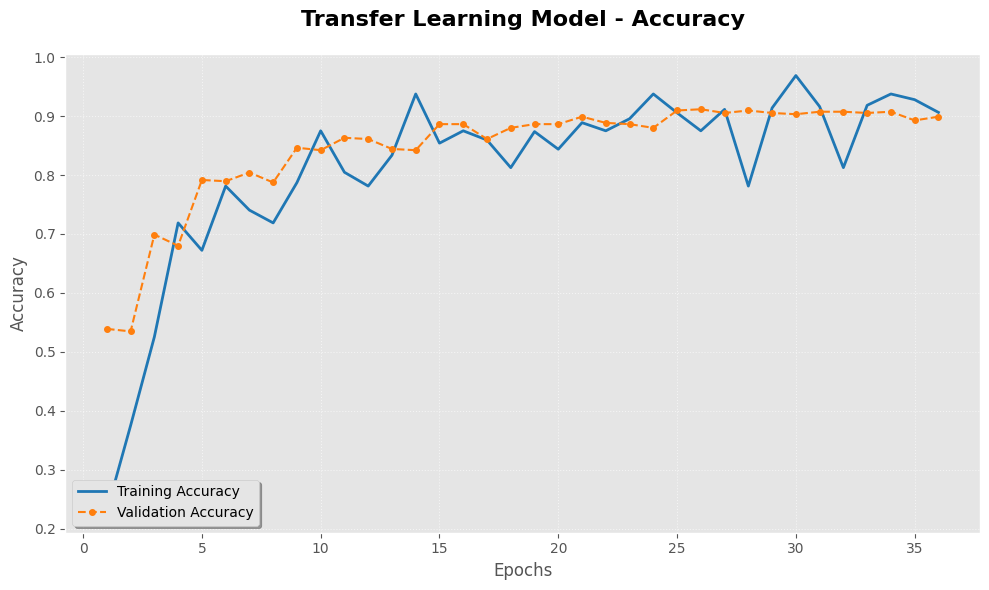

In [ ]:
# Plot history
plot_history(tl_model_history, tl_model_title, 'accuracy')

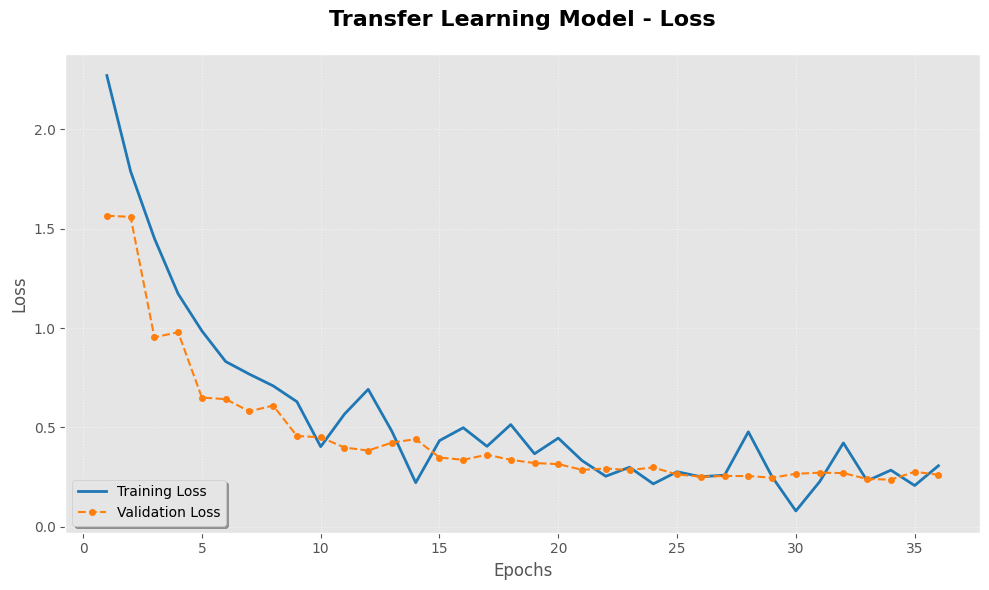

In [ ]:
plot_history(tl_model_history, tl_model_title, 'loss')

### Observations


1.   For Transfer Learning Model the accuracy for validation increased along with the epochs.
2.   The training accuracy didn't increase too much and actually declined. Not good!
3. The Transfer Learning Model's training loss declined as the epochs increased and the validation losses were more consistent.
4. The model is improving its predictions on the training data by minimizing the error (loss) during backpropagation.
5. The training accuracy is not enough to evaluate the model's performance.



In [ ]:
# Evaluate model
start_time = start_timer()
show_banner(tl_model_title, 'Evaluation')

tl_model_loss, tl_model_accuracy = evalute_model(
    tl_model,
    x_testing_normalized,
    y_testing_encoded
)

show_timer(start_time)



# =========================
#  TRANSFER LEARNING MODEL
# =========================
Evaluation

15/15 - 12s - 786ms/step - accuracy: 0.9116 - loss: 0.2588
Test Loss: 0.2588486075401306, Test Accuracy: 0.9115789532661438

Run Time: 0m 12s 55ms


In [ ]:
# Model performance classification
tl_model_training_perf = model_performance_classification(tl_model, x_training_normalized, y_training_encoded)
tl_model_training_perf

119/119 ━━━━━━━━━━━━━━━━━━━━ 12s 94ms/step


,Accuracy,Precision,Recall,F1
0,0.948684,0.949807,0.948684,0.948814


In [ ]:
# Get prediction data for new model
y_predictor_training, y_predictor_testing, y_testing_normalized = get_model_predictions(
    tl_model,
    x_training_normalized,
    x_testing_normalized,
    y_testing_encoded
)

119/119 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step


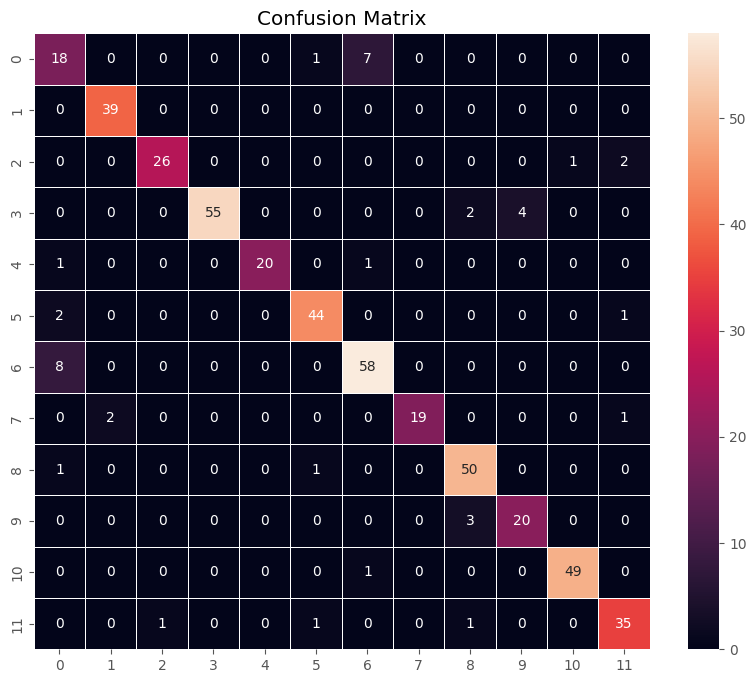

In [ ]:
# Plot confusion matrix
plot_confusion_matrix(y_testing_encoded, y_predictor_testing)

# ----- [0 of 4] ----- #
Index:309

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


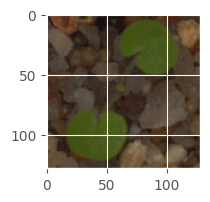

Predicted Label: Small-flowered Cranesbill
True Label:  Small-flowered Cranesbill
✅ Correct Prediction!
# ----- [END] ----- #


# ----- [1 of 4] ----- #
Index:78

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


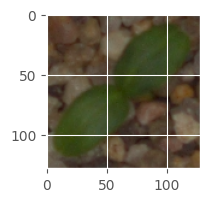

Predicted Label: Cleavers
True Label:  Cleavers
✅ Correct Prediction!
# ----- [END] ----- #


# ----- [2 of 4] ----- #
Index:347

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


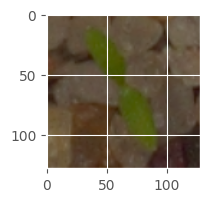

Predicted Label: Common Chickweed
True Label:  Common Chickweed
✅ Correct Prediction!
# ----- [END] ----- #


# ----- [3 of 4] ----- #
Index:230

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


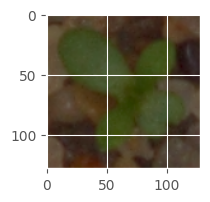

Predicted Label: Scentless Mayweed
True Label:  Scentless Mayweed
✅ Correct Prediction!
# ----- [END] ----- #



Run Time: 0m 2s 431ms


# =========================
#  TRANSFER LEARNING MODEL
# =========================
4 / 4 
Prediction Accuracy: 100.00%



In [ ]:
# Display visualization prediction model
start_time = start_timer()
prediction_correct, total = show_visualize_prediction(
    tl_model,
    label_encoder,
    x_testing_data,
    x_testing_normalized,
    y_testing_encoded,
)

show_timer(start_time)

pct = (prediction_correct / total) * 100
show_banner(tl_model_title, f'{prediction_correct} / {total} \nPrediction Accuracy: {pct:.2f}%')

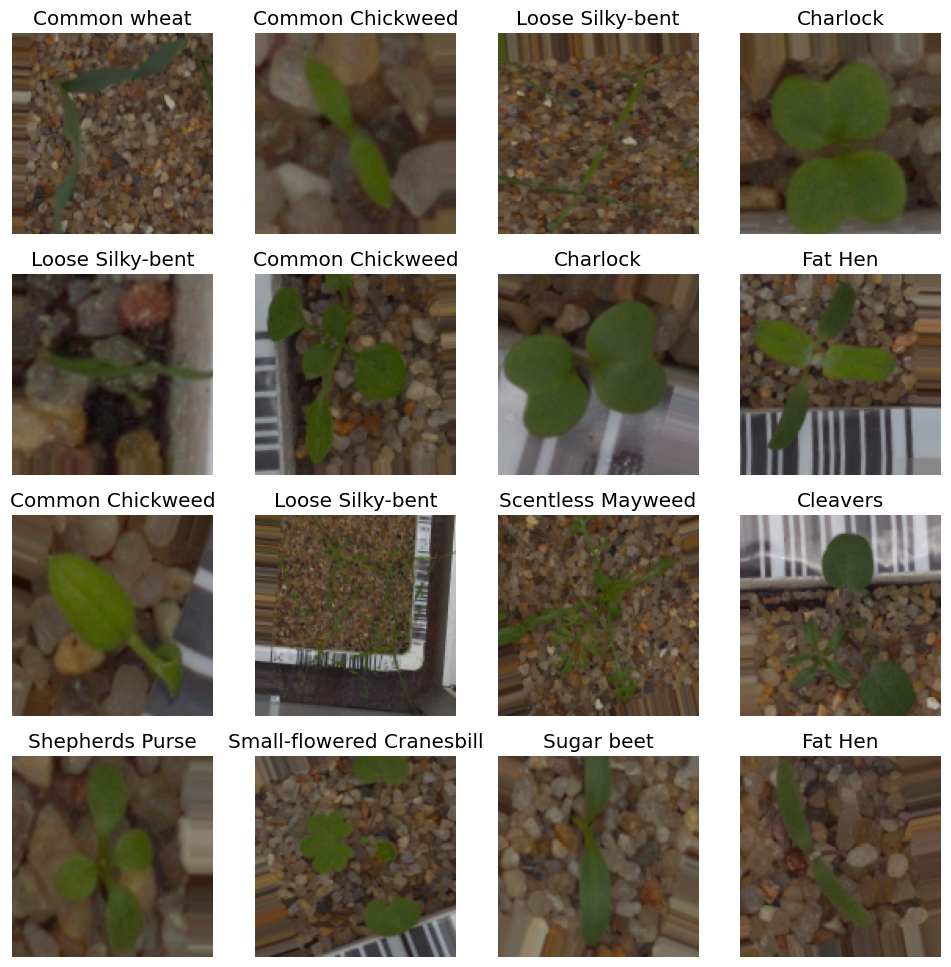

In [ ]:
# Show images of manipulated data prior to training
visualize_augmented_image_batch(training_generator, label_encoder)

In [ ]:
show_banner(tl_model_title + ' with '+ vgg_model_title, 'Classification Report')
print_classification_report(tl_model, x_testing_normalized, y_testing_encoded)



# ==========================================
#  TRANSFER LEARNING MODEL WITH VGG16 MODEL
# ==========================================
Classification Report

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step
                           precision    recall  f1-score   support

              Black-grass     0.6000    0.6923    0.6429        26
                 Charlock     0.9512    1.0000    0.9750        39
                 Cleavers     0.9630    0.8966    0.9286        29
         Common Chickweed     1.0000    0.9016    0.9483        61
             Common wheat     1.0000    0.9091    0.9524        22
                  Fat Hen     0.9362    0.9362    0.9362        47
         Loose Silky-bent     0.8657    0.8788    0.8722        66
                    Maize     1.0000    0.8636    0.9268        22
        Scentless Mayweed     0.8929    0.9615    0.9259        52
          Shepherds Purse     0.8333    0.8696    0.8511        23
Small-flowered Cranesbill     0.9800    0.9800    0.9800       

Conclusions

In [ ]:
base_training_perf

,Accuracy,Precision,Recall,F1
0,0.968947,0.96967,0.968947,0.96892


In [ ]:
da_model_training_perf

,Accuracy,Precision,Recall,F1
0,0.728421,0.736019,0.728421,0.724314


In [ ]:
tl_model_training_perf

,Accuracy,Precision,Recall,F1
0,0.948684,0.949807,0.948684,0.948814


### Final Results

In [ ]:
# ==================================
#  FINAL RESULT METRICS
# ==================================
#
# Training Accuracy: >= 90%
# Validation Accuracy: >= 85%
# Testing Accuracy: >= 85%
# Testing Loss: <= 50% (want it closes to 0)

# Build model performance graph.
models = []
models.append(base_model_title)
models.append(da_model_title)
models.append(tl_model_title)

# Indicates how well the model is learning the input data.
training_accuracy = []
training_accuracy.append(base_model_history.history['accuracy'][-1])
training_accuracy.append(da_model_history.history['accuracy'][-1])
training_accuracy.append(tl_model_history.history['accuracy'][-1])

# Used during the training process to provide a proxy for generalization.  A gap
# between this and Training Accuracy is a key sign of overfitting.
validation_accuracy = []
validation_accuracy.append(base_model_history.history['val_accuracy'][-1])
validation_accuracy.append(da_model_history.history['val_accuracy'][-1])
validation_accuracy.append(tl_model_history.history['val_accuracy'][-1])

# MOST IMPORTANT!!!
# Measures model's performance on completely unseen data that was held out
# specifically for final evaluation
testing_accuracy = []
testing_accuracy.append(base_model_accuracy)
testing_accuracy.append(da_model_accuracy)
testing_accuracy.append(tl_model_accuracy)

# Tests the magnitude of the error the model makes on the unseen test data.
testing_loss = []
testing_loss.append(base_model_loss)
testing_loss.append(da_model_loss)
testing_loss.append(tl_model_loss)

In [ ]:
# Creating matrix to view final data
pd.DataFrame({
    'Models': models,
    'Training Accuracy': training_accuracy,
    'Validation Accuracy': validation_accuracy,
    'Testing Accuracy': testing_accuracy,
    'Testing Loss': testing_loss,
})

,Models,Training Accuracy,Validation Accuracy,Testing Accuracy,Testing Loss
0,Base CNN Model,0.905263,0.806316,0.840000,0.790916
1,Data Augmented CNN Model,0.687500,0.652632,0.732632,0.851914
2,Transfer Learning Model,0.906250,0.898947,0.911579,0.258849


## Actionable Insights and Business Recommendations

*   The model correctly identified seedlingss.
*   The predictor value for each model was high enough to correctly identify which seedlings was which.
* Augmenting the data with encoders changed the accuracy and the loss dramatically.
* Transfer Learning helped with the final model in identifying seedlingss compared to the augmented one.
* Training these models at 64x64 sufficed although 128px would probably be better.
* The size of the filtering helped determine the results.  
* The base CNN model was the best and efficient model to identify the seedlingss.
* CNN Model accuracy was 95.2%.
* CNN Model with Augmented Data was 71%.
* Transfer Learning Model was at 92%.
* Visualizing the prediction displayed the correct results the majority of the time!
* The Image Data Manipulator was the biggest factor in determining accuracy.
* Have better photos that show plants at various stages of growth.
* Keep backgrounds consistent so that we can focus on the seedlings/plants.
* 12 different seedlingss suffice but wouldn't hurt to have a few more.
* There will be economic benefits with using automation to detect seedlings in the future.



_____

# **End of Program**